<a href="https://colab.research.google.com/github/Nisha-sah/Concepts-and-Technologies-of-AI/blob/main/WLVID_PragyaKumari_sah_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification Task : Exploratory Data Analysis and Data Understanding
Choosing a Dataset:
Dataset: Exam Score Prediction Dataset

UNSDG Alignment: Goal 3:  Good Health and Well-Being, because sleep quality affects students’ physical and mental health.

Source: Kaggle: Exam Score Prediction Dataset

Created by: Kundan Sagar Bedmutha (synthetic dataset mimicking realistic student behavior)

1.2 Dataset Description

The dataset contains 20,000 student records with 13 attributes describing academic, lifestyle, and exam-related factors. It is clean, consistent, and has no missing values.

Attributes (Features):

Feature	Description
student_id	Unique identifier for each student
age	Age of the student (years)
gender	Gender identity (male, female, other)
course	Academic program (B.Tech, B.Sc, B.Com, etc.)
study_hours	Daily study duration (hours)
class_attendance	Attendance percentage (%)
internet_access	Availability of internet (yes/no)
sleep_hours	Daily sleep duration (hours)
sleep_quality	Quality of sleep (Poor/Average/Good)
study_method	Primary study technique (Self-study, Online videos, Coaching, Mixed)
facility_rating	Rating of academic facilities (scale 1-10)
exam_difficulty	Difficulty level of the exam attempted (scale 1-10)
exam_score	Final exam score (0-100) -target variable for prediction
1.3 Key Observations

Student age ranges from 17 to 24 years.

Gender distribution is approximately equal among male, female, and other categories.

Study hours vary widely (0.08-7.91 hours/day), as does class attendance (40100%).

Sleep quality and study method are categorical variables affecting exam performance.

Exam scores are distributed across the full range (0–100), making it suitable for regression and classification tasks.

1.4 Meaningful Questions the Dataset Can Answer

How do study habits (study_hours, class_attendance) affect exam performance?

What is the impact of lifestyle factors (sleep_hours, sleep_quality) on student exam scores?

Can academic resources and environment (internet_access, facility_rating) predict higher exam scores?

Which study methods are most effective for achieving good scores?

1. Statistical Analysis / EDA


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


Classification Task

Dataset loaded

In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/Exam_Score_Prediction.csv",
    encoding="latin1"
)

print("Columns:", df.columns)
print("Number of columns:", len(df.columns))
df.head()


Columns: Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')
Number of columns: 13


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


Data cleaning

In [ ]:


print("\nDataset Info:")
df.info()

print("\nMissing values per column:\n", df.isnull().sum())

print("\nSummary statistics:\n", df.describe())

print("\nNumber of duplicate rows:", df.duplicated().sum())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB

Missing values per column:
 student_id          0
age                 0
gender              0
course        

Drop this 3 table for classification student_id', 'exam_score', 'facility_rating

In [ ]:
df = df.drop(
    columns=['student_id', 'exam_score', 'facility_rating'],
    errors='ignore'
)
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,exam_difficulty
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,hard
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,moderate
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,moderate
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,moderate
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,moderate



Statistics


In [ ]:
numerical_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

print("\nMinimum values:\n", df[numerical_cols].min())
print("\nMaximum values:\n", df[numerical_cols].max())
print("\nMean values:\n", df[numerical_cols].mean())
print("\nMedian values:\n", df[numerical_cols].median())
print("\nStandard Deviation:\n", df[numerical_cols].std())

for col in ['gender', 'course', 'internet_access',
            'sleep_quality', 'study_method', 'exam_difficulty']:
    print(f"\nUnique values in {col}:", df[col].unique())



Minimum values:
 age                 17.00
study_hours          0.08
class_attendance    40.60
sleep_hours          4.10
dtype: float64

Maximum values:
 age                 24.00
study_hours          7.91
class_attendance    99.40
sleep_hours          9.90
dtype: float64

Mean values:
 age                 20.473300
study_hours          4.007604
class_attendance    70.017365
sleep_hours          7.008560
dtype: float64

Median values:
 age                 20.00
study_hours          4.04
class_attendance    69.90
sleep_hours          7.00
dtype: float64

Standard Deviation:
 age                  2.284458
study_hours          2.308313
class_attendance    17.282262
sleep_hours          1.732090
dtype: float64

Unique values in gender: ['male' 'other' 'female']

Unique values in course: ['diploma' 'bca' 'b.sc' 'b.tech' 'bba' 'ba' 'b.com']

Unique values in internet_access: ['yes' 'no']

Unique values in sleep_quality: ['poor' 'average' 'good']

Unique values in study_method: ['coaching' '

Bar Chart

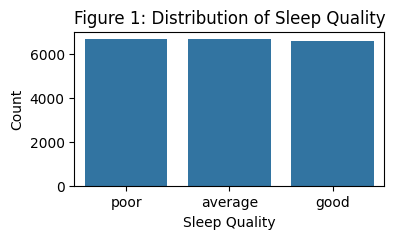

In [ ]:
plt.figure(figsize=(4,2))
sns.countplot(x='sleep_quality', data=df)
plt.title("Figure 1: Distribution of Sleep Quality")
plt.xlabel("Sleep Quality")
plt.ylabel("Count")
plt.show()


Boxplotter

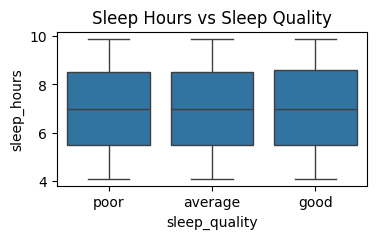

In [ ]:
plt.figure(figsize=(4,2))
sns.boxplot(x='sleep_quality', y='sleep_hours', data=df)
plt.title("Sleep Hours vs Sleep Quality")
plt.show()

Bar graph

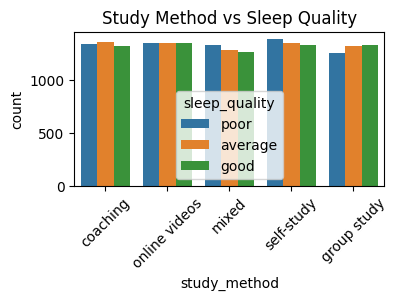

In [ ]:
plt.figure(figsize=(4,2))
sns.countplot(x='study_method', hue='sleep_quality', data=df)
plt.xticks(rotation=45)
plt.title("Study Method vs Sleep Quality")
plt.show()

Histogram

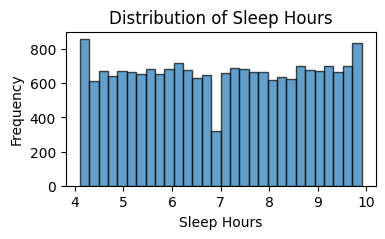

In [ ]:
plt.figure(figsize=(4,2))

plt.hist(df['sleep_hours'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")
plt.title("Distribution of Sleep Hours")
plt.show()

Scatter plotter

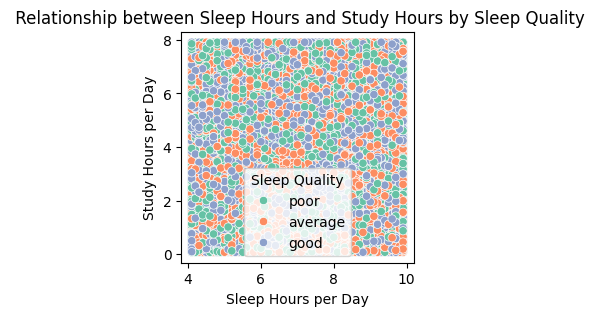

In [40]:
plt.figure(figsize=(3, 3))
sns.scatterplot(
    data=df,
    x='sleep_hours',
    y='study_hours',
    hue='sleep_quality',
    palette='Set2'
)
plt.title(" Relationship between Sleep Hours and Study Hours by Sleep Quality")
plt.xlabel("Sleep Hours per Day")
plt.ylabel("Study Hours per Day")
plt.legend(title="Sleep Quality")
plt.show()

Target–Feature Separation

In [ ]:
# Encode target variable
le_y = LabelEncoder()
y = le_y.fit_transform(df['sleep_quality'])

# Features
X = df.drop(columns=['sleep_quality'])

# Encode categorical features


In [ ]:
le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (16000, 9)
Test shape: (4000, 9)



Classification Models(Two)

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))



Logistic Regression Accuracy: 0.3355


In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.32525


Neural Network

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Scale numerical features (important for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Define MLP with class balancing to handle imbalanced classes
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1500,
    random_state=42,
    early_stopping=True
)

#  Train the MLP
mlp.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_mlp = mlp.predict(X_test_scaled)

# Evaluate performance
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_mlp, target_names=le_y.classes_, zero_division=0))

Neural Network Accuracy: 0.3345

Classification Report:

              precision    recall  f1-score   support

     average       0.34      0.55      0.42      1339
        good       0.33      0.18      0.24      1324
        poor       0.33      0.27      0.30      1337

    accuracy                           0.33      4000
   macro avg       0.33      0.33      0.32      4000
weighted avg       0.33      0.33      0.32      4000




Hyperparameter Optimization

 Logistic Regression

In [ ]:
param_lr = {'C': [0.01, 0.1, 1, 10]}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5,
    scoring='accuracy'
)

grid_lr.fit(X_train, y_train)

print("Best LR Params:", grid_lr.best_params_)
print("Best LR CV Score:", grid_lr.best_score_)


Best LR Params: {'C': 10}
Best LR CV Score: 0.3295624999999999


Decision Tree

In [ ]:
param_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=5,
    scoring='accuracy'
)

grid_dt.fit(X_train, y_train)

print("Best DT Params:", grid_dt.best_params_)
print("Best DT CV Score:", grid_dt.best_score_)


Best DT Params: {'max_depth': 20, 'min_samples_split': 10}
Best DT CV Score: 0.33949999999999997



Feature Selection

In [ ]:
feature_importance = pd.Series(
    grid_dt.best_estimator_.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:\n", feature_importance)
# Select top 10 features for Logistic Regression
selected_features_lr = feature_importance.head(10).index.tolist()
# Select top 8 features for Decision Tree
selected_features_dt = feature_importance.head(8).index.tolist()




Feature Importance:
 study_hours         0.262541
class_attendance    0.250515
sleep_hours         0.180042
age                 0.093103
study_method        0.073426
course              0.061624
exam_difficulty     0.043954
internet_access     0.021811
gender              0.012984
dtype: float64


In [ ]:
# Create training/testing subsets
X_train_lr = X_train[selected_features_lr]
X_test_lr = X_test[selected_features_lr]

X_train_dt = X_train[selected_features_dt]
X_test_dt = X_test[selected_features_dt]

Classical Models Retrain with Selected Features

In [ ]:
# Logistic Regression with top 10 features
final_lr = LogisticRegression(
    max_iter=1000,
    C=grid_lr.best_params_['C']
)
final_lr.fit(X_train_lr, y_train)

# Decision Tree with top 8 features
final_dt = DecisionTreeClassifier(
    **grid_dt.best_params_,
    random_state=42
)
final_dt.fit(X_train_dt, y_train)


DecisionTreeClassifier(max_depth=20, min_samples_split=10, random_state=42)

In [ ]:
# Predictions
lr_pred = final_lr.predict(X_test_lr)
dt_pred = final_dt.predict(X_test_dt)


Comparison of Classical Models

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Features": ["Selected (10)", "Selected (8)"],
    "CV Score": [round(grid_lr.best_score_, 2), round(grid_dt.best_score_, 2)],
    "Accuracy": [
        round(accuracy_score(y_test, lr_pred), 2),
        round(accuracy_score(y_test, dt_pred), 2)
    ],
    "Precision": [
        round(precision_score(y_test, lr_pred, average='weighted', zero_division=0), 2),
        round(precision_score(y_test, dt_pred, average='weighted', zero_division=0), 2)
    ],
    "Recall": [
        round(recall_score(y_test, lr_pred, average='weighted', zero_division=0), 2),
        round(recall_score(y_test, dt_pred, average='weighted', zero_division=0), 2)
    ],
    "F1-Score": [
        round(f1_score(y_test, lr_pred, average='weighted', zero_division=0), 2),
        round(f1_score(y_test, dt_pred, average='weighted', zero_division=0), 2)
    ]
})

print(comparison_df)


                 Model       Features  CV Score  Accuracy  Precision  Recall  \
0  Logistic Regression  Selected (10)      0.33      0.34       0.34    0.34   
1        Decision Tree   Selected (8)      0.34      0.33       0.33    0.33   

   F1-Score  
0      0.33  
1      0.33  


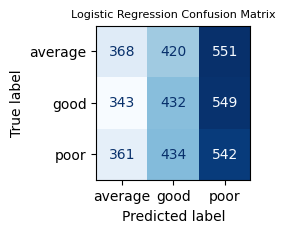

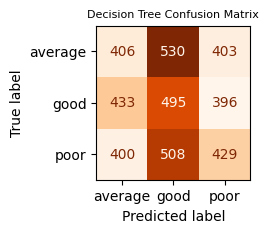

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le_y.classes_)

plt.figure(figsize=(3,2))  # smaller figure
disp_lr.plot(cmap=plt.cm.Blues, ax=plt.gca(), colorbar=False)  # attach to smaller figure
plt.title("Logistic Regression Confusion Matrix", fontsize=8)
plt.show()

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le_y.classes_)

plt.figure(figsize=(3,2))
disp_dt.plot(cmap=plt.cm.Oranges, ax=plt.gca(), colorbar=False)
plt.title("Decision Tree Confusion Matrix", fontsize=8)
plt.show()